<a href="https://colab.research.google.com/github/abhiniveshg0-max/DEEP-LEARNING/blob/main/experiment%20no%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7579 - loss: 0.5350 - val_accuracy: 0.8913 - val_loss: 0.3802
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9511 - loss: 0.2816 - val_accuracy: 0.9348 - val_loss: 0.2345
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9707 - loss: 0.1704 - val_accuracy: 0.9348 - val_loss: 0.1667
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9780 - loss: 0.1212 - val_accuracy: 0.9565 - val_loss: 0.1324
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9780 - loss: 0.0974 - val_accuracy: 0.9565 - val_loss: 0.1041
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9853 - loss: 0.0825 - val_accuracy: 0.9565 - val_loss: 0.0889
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9853 - loss: 0.0732 - val_accuracy: 0.9783 - val_loss: 0.0780
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9853 - loss: 0.0663 - val_accuracy: 0.9783 - v

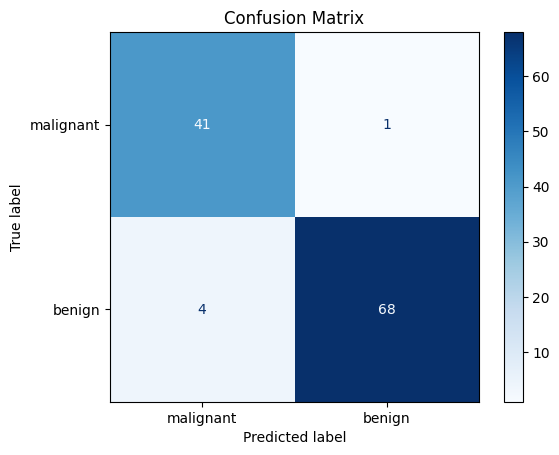

In [1]:
# EXPT NO: 1 - PART B: ANN FOR CLASSIFICATION
# Dataset: Breast Cancer Wisconsin Dataset
# Roll No: YOUR_ROLL_NO

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 1. Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Standardize Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Build ANN Model
model = tf.keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 5. Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# 7. Predict
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

# 8. Evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nResults")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-Score :", f1)

print("\nConfusion Matrix")
print(cm)

# 9. Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()